## Data Preprocessing

In [86]:
# load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv('bank_marketing_dataset.csv')
df.head()




,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [87]:
df.columns = df.columns.str.strip().str.lower()
df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [89]:
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [90]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [91]:
df.duplicated().sum()


np.int64(0)

In [92]:
numerical_cols = [
    'age', 'balance', 'duration', 'campaign', 'pdays', 'previous'
]

df[numerical_cols].describe()


,age,balance,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,3881.000000,63.000000,854.000000,58.000000


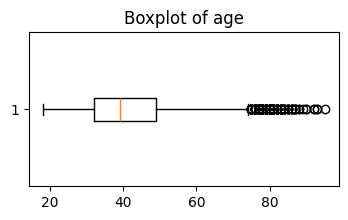

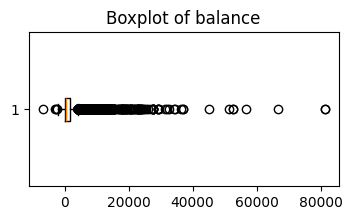

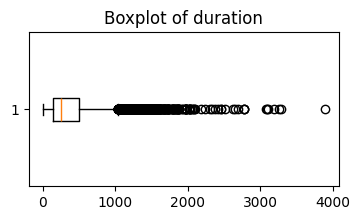

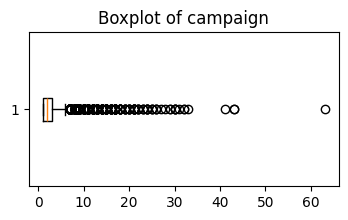

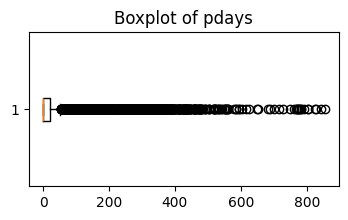

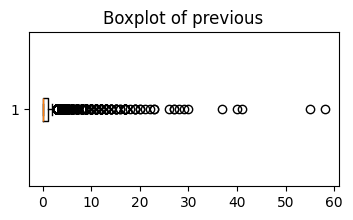

In [93]:
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure(figsize=(4,2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.show()


In [94]:
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) |
            (df[numerical_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()


age          171
balance     1055
duration     636
campaign     601
pdays       2750
previous    1258
dtype: int64

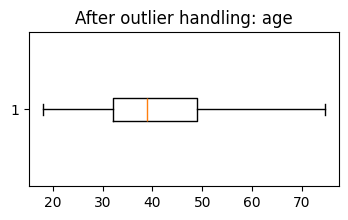

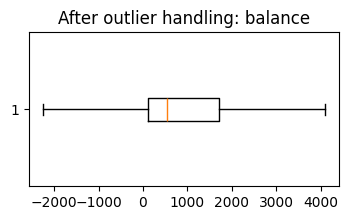

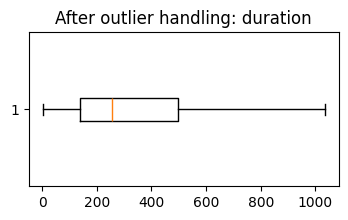

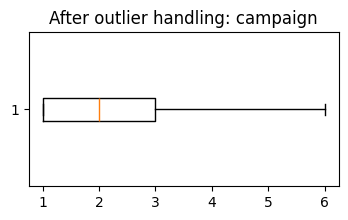

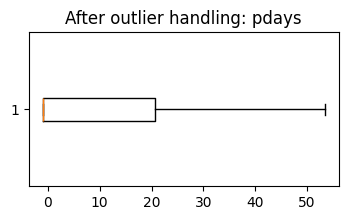

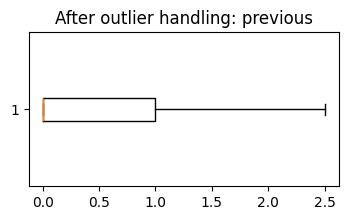

In [95]:
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
    return df
df = cap_outliers_iqr(df, num_cols)

import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(4,2))
    plt.boxplot(df[col], vert=False)
    plt.title(f'After outlier handling: {col}')
    plt.show()

In [96]:
df['deposit'].value_counts(dropna=False)


deposit
no     5873
yes    5289
Name: count, dtype: int64

In [97]:
df['deposit'].unique()


array(['yes', 'no'], dtype=object)

In [98]:
df['deposit'] = df['deposit'].astype(str).str.strip().str.lower()



In [99]:
df['deposit'].value_counts(dropna=False)


deposit
no     5873
yes    5289
Name: count, dtype: int64

In [100]:
df['deposit'].unique()


array(['yes', 'no'], dtype=object)

In [101]:
df[['age', 'job', 'balance', 'loan', 'contact']].describe(include='all')


,age,job,balance,loan,contact
count,11162.000000,11162,11162.000000,11162,11162
unique,NaN,12,NaN,2,3
top,NaN,management,NaN,no,cellular
freq,NaN,2566,NaN,9702,8042
mean,41.152347,NaN,1117.352804,NaN,NaN
std,11.659113,NaN,1349.670734,NaN,NaN
min,18.000000,NaN,-2257.000000,NaN,NaN
25%,32.000000,NaN,122.000000,NaN,NaN
50%,39.000000,NaN,550.000000,NaN,NaN
75%,49.000000,NaN,1708.000000,NaN,NaN


In [102]:
features = [
    'age', 'job', 'balance', 'housing', 'loan',
    'contact', 'duration', 'campaign', 'pdays', 'previous'
]

X = df[features]
y = df['deposit']



In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [104]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,age,balance,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,housing_yes,loan_yes,contact_telephone,contact_unknown
0,59.0,2343,1033,1,-1.0,0.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,56.0,45,1033,1,-1.0,0.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,41.0,1270,1033,1,-1.0,0.0,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
3,55.0,2476,579,1,-1.0,0.0,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
4,54.0,184,673,2,-1.0,0.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [105]:
X.dtypes


age                  float64
balance                int64
duration               int64
campaign               int64
pdays                float64
previous             float64
job_blue-collar         bool
job_entrepreneur        bool
job_housemaid           bool
job_management          bool
job_retired             bool
job_self-employed       bool
job_services            bool
job_student             bool
job_technician          bool
job_unemployed          bool
job_unknown             bool
housing_yes             bool
loan_yes                bool
contact_telephone       bool
contact_unknown         bool
dtype: object

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [107]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [108]:
y_pred = model.predict(X_test)


In [109]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)


Accuracy: 0.7814599193909538

Classification Report:
               precision    recall  f1-score   support

          no       0.81      0.75      0.78      1166
         yes       0.75      0.81      0.78      1067

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233



array([[878, 288],
       [200, 867]])

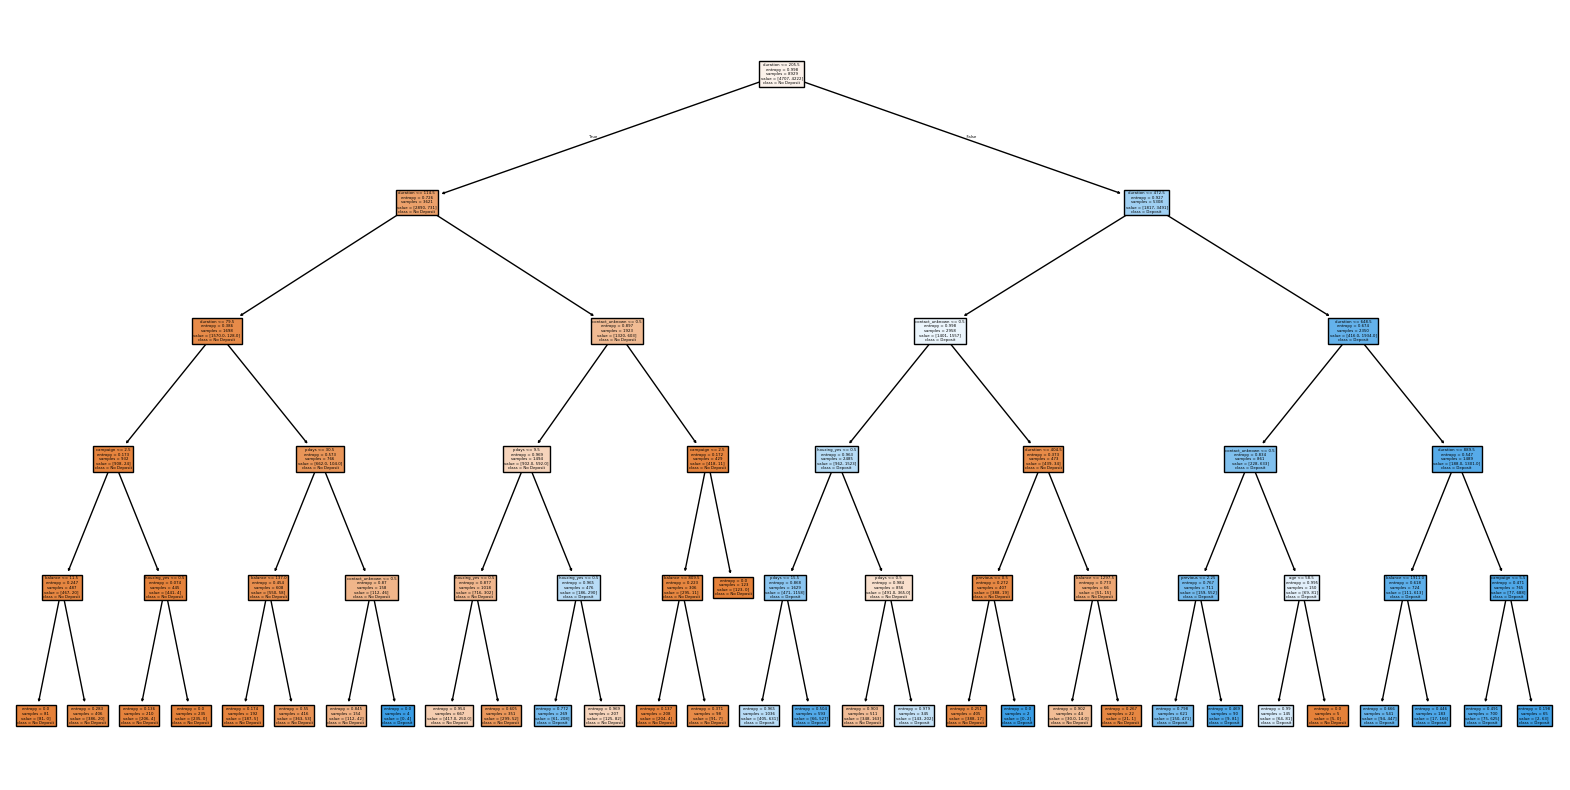

In [110]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No Deposit', 'Deposit'],
    filled=True
)
plt.show()


In [111]:
#unseen data prediction
unseen_data = pd.DataFrame({
    'age': [30, 45],
    'job': ['technician', 'management'],
    'balance': [1500, 3000],
    'housing': ['yes', 'no'],
    'loan': ['no', 'yes'],
    'contact': ['cellular', 'telephone'],
    'duration': [200, 150],
    'campaign': [1, 2],
    'pdays': [999, 5],
    'previous': [0, 1]
})
unseen_data = pd.get_dummies(unseen_data, drop_first=True)
unseen_data = unseen_data.reindex(columns=X.columns, fill_value=0)
predictions = model.predict(unseen_data)
print("Predictions for unseen data:", predictions)


Predictions for unseen data: ['no' 'no']


In [112]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']


In [113]:
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
    return df


In [114]:
df = cap_outliers_iqr(df, num_cols)


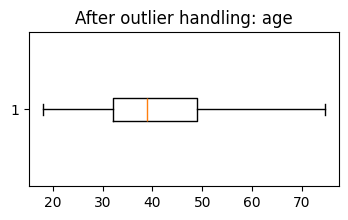

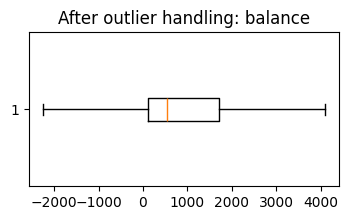

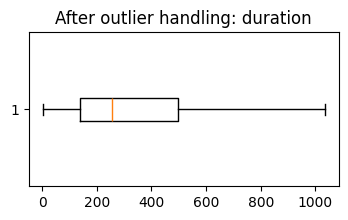

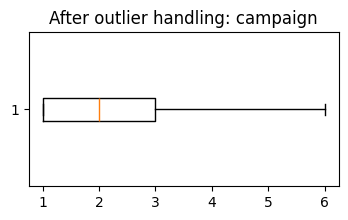

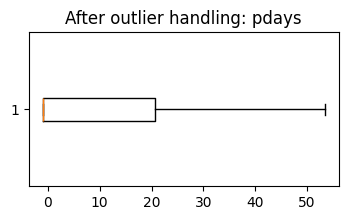

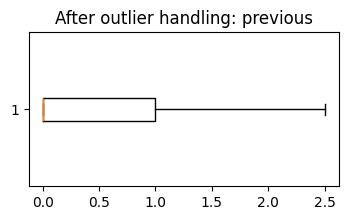

In [115]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(4,2))
    plt.boxplot(df[col], vert=False)
    plt.title(f'After outlier handling: {col}')
    plt.show()
